Visualizing all mazes defined in 'mazes.py':


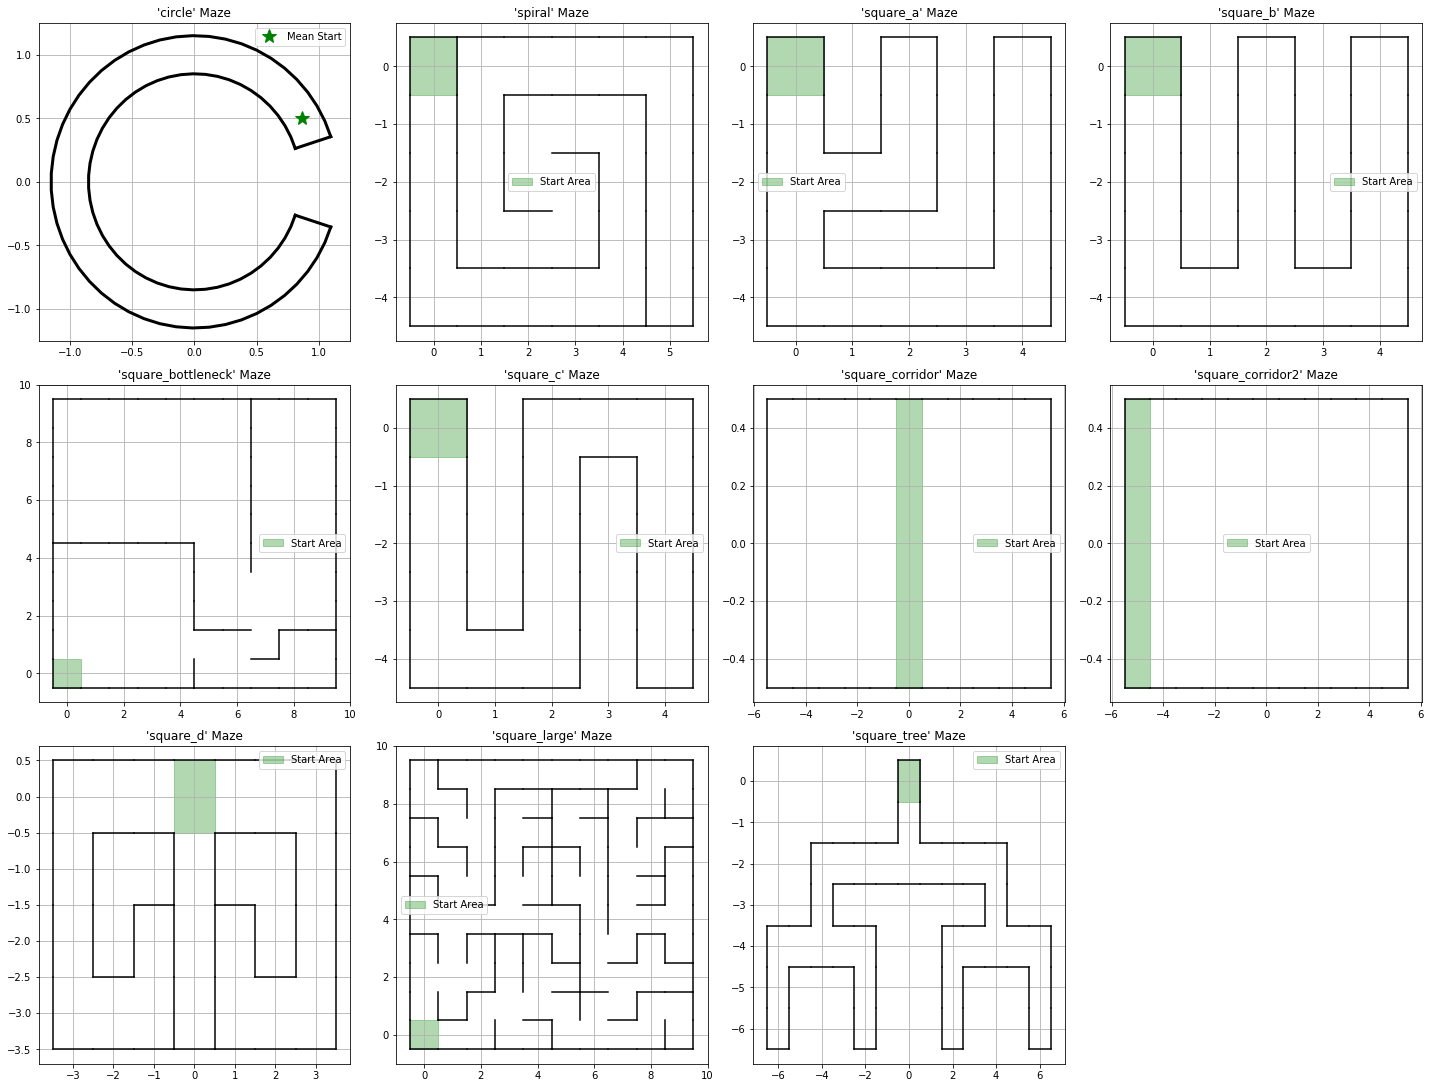

In [2]:
import os
import sys
import matplotlib.pyplot as plt
import math

# Add the project root to the Python path to allow imports from the agents module
sys.path.append("..")
os.environ["ROOT_DIR"] = ".."  # this allows to use relative paths in config files

from agents.maze_agents.toy_maze.env.mazes import mazes_dict, Maze, CircleMaze

# Get the names of all mazes defined in mazes_dict, sorted alphabetically.
maze_names = sorted(mazes_dict.keys())
num_mazes = len(maze_names)

if num_mazes == 0:
    raise Exception("No mazes found in mazes_dict.")

# Calculate the grid size for subplots to display all mazes.
grid_size = int(math.ceil(math.sqrt(num_mazes)))

# Create the figure and axes for the subplots.
fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 5, grid_size * 5))

# Flatten the axes array for easy iteration, handle case where grid_size=1
if num_mazes > 1:
    axes = axes.flatten()
else:
    axes = [axes]

print("Visualizing all mazes defined in 'mazes.py':")

for i, maze_name in enumerate(maze_names):
    ax = axes[i]
    try:
        maze_object = mazes_dict[maze_name]['maze']

        # Plot the maze walls.
        maze_object.plot(ax)

        # --- Visualize Start Locations ---
        if isinstance(maze_object, Maze):
            # For grid-based mazes, highlight the start squares.
            if hasattr(maze_object, 'start_squares') and maze_object.start_squares:
                for start_square_name in maze_object.start_squares:
                    if start_square_name in maze_object._segments:
                        loc = maze_object._segments[start_square_name]['loc']
                        # Draw a semi-transparent green square over the start area.
                        rect = plt.Rectangle((loc[0] - 0.5, loc[1] - 0.5), 1, 1,
                                                color='g', alpha=0.3, label='Start Area')
                        ax.add_patch(rect)
        elif isinstance(maze_object, CircleMaze):
            # For the circle maze, plot the mean start point.
            if hasattr(maze_object, 'mean_s0'):
                mean_s0 = maze_object.mean_s0
                ax.plot(mean_s0[0], mean_s0[1], 'g*', markersize=15, label='Mean Start')

        # Set title and grid.
        ax.set_title("'{}' Maze".format(maze_name))
        ax.grid(True)

        # --- Handle Legend ---
        # To avoid duplicate labels, create a legend from unique labels only.
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        if by_label:
            ax.legend(by_label.values(), by_label.keys())

    except Exception as e:
        ax.text(0.5, 0.5, 'Error plotting:\n{}'.format(e), ha='center', va='center')
        ax.set_title("'{}' Maze - FAILED".format(maze_name))

# Hide any unused subplots.
for i in range(num_mazes, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

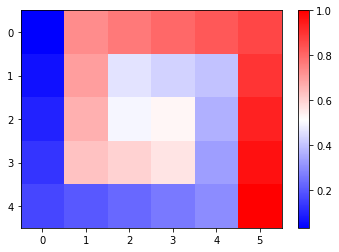

In [12]:
import numpy as np
import matplotlib.pyplot as plt

spiral_maze = np.array([
    [1,22,23,24,25,26],
    [2,21,14,13,12,27],
    [3,20,15,16,11,28],
    [4,19,18,17,10,29],
    [5,6,7,8,9,30],
])

spiral_maze = spiral_maze / 30

plt.imshow(spiral_maze, cmap='bwr')
plt.colorbar()
plt.show()